In [6]:
import os
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
# Mount into drive

from google.colab import drive

drive.mount("/content/drive")
#! ls /content/drive
%cd '/content/drive/Othercomputers/MyMac/CS7643_DL/crytpo_DLOB'

!pip install -r requirements_jing.txt


Mounted at /content/drive
/content/drive/Othercomputers/MyMac/CS7643_DL/crytpo_DLOB
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 127.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 105.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 55.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.2/179.2 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [7]:
# Cell 1: Imports (Make sure these are at the top of your notebook)
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
from torch.utils.data import Dataset, DataLoader
import gc
import os
import sys
import yaml
from preprocessing.preprocessing import preprocess_lob_data, split_data_chronological, normalize_features
from preprocessing.dataset import create_sequences, LOBSequenceDataset
from training.trainer import Trainer, Config

In [8]:
print(os.getcwd())

/content/drive/Othercomputers/MyMac/CS7643_DL/crytpo_DLOB


In [9]:

with open("configs/mlplob.cfg", "r") as f:
    config_dict = yaml.safe_load(f)
config = Config(config_dict)

In [10]:
device = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [11]:
# --- 1. Preprocess Data ---
df_processed = preprocess_lob_data(config)
gc.collect()

Memory Usage: 1543.83 MB
Shape before cleaning (dropna): (4817923, 81)
NaN count before: 0
Shape after cleaning: (4817923, 81)
NaN count after: 0
Calculating alpha dynamically...
Dynamic alpha = 0.000072
Shape after label creation and NaN drop: (4817823, 44)
Label distribution:
label
1    0.468476
2    0.267162
0    0.264362
Name: proportion, dtype: float64
Saving preprocessed data to results/...
Save complete.


0

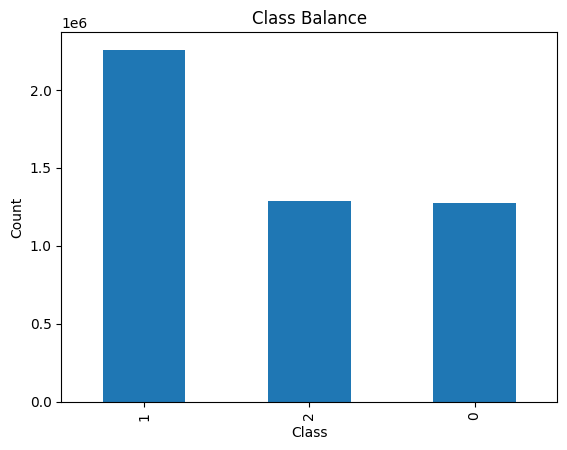

In [12]:
import matplotlib.pyplot as plt
class_counts = df_processed['label'].value_counts()
# Plot
class_counts.plot(kind='bar')
plt.title('Class Balance')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [13]:
# --- 2. Split Data ---
train_df, val_df, test_df = split_data_chronological(
    df_processed,
    train_frac=config_dict['split_fractions']['train'],
    val_frac=config_dict['split_fractions']['val'],
    test_frac=config_dict['split_fractions']['test']
)
del df_processed
gc.collect()

Data Split: Train=3372476, Val=722673, Test=722674


2810

In [14]:
train_df.head()

,b0,b1,b2,b3,b4,b5,b6,b7,b8,b9,...,aq4,aq5,aq6,aq7,aq8,aq9,mid_price,spread,vol_imbalance_10,label
50,70292.523438,70291.828125,70291.812500,70291.460938,70290.242188,70288.500000,70288.476562,70288.468750,70288.320312,70287.609375,...,0.024139,0.032386,0.067155,0.00867,0.011392,0.142374,70292.53125,0.007812,0.326259,2
51,70292.523438,70291.812500,70291.460938,70291.437500,70290.242188,70289.359375,70288.906250,70288.500000,70288.320312,70286.593750,...,0.092469,0.032386,0.035563,0.05280,0.215270,0.008670,70292.53125,0.007812,-0.322852,2
52,70292.523438,70291.812500,70291.460938,70291.437500,70290.242188,70289.359375,70288.500000,70288.320312,70286.593750,70286.578125,...,0.024139,0.032386,0.035563,0.21527,0.008670,0.116370,70292.53125,0.007812,0.100118,2
53,70292.523438,70291.812500,70291.460938,70291.437500,70290.242188,70289.359375,70289.007812,70288.500000,70288.320312,70286.593750,...,0.024139,0.032386,0.035563,0.21527,0.008670,0.116370,70292.53125,0.007812,-0.175461,2
54,70292.523438,70291.812500,70291.460938,70291.437500,70290.242188,70289.359375,70289.007812,70288.500000,70288.320312,70286.593750,...,0.032386,0.035563,0.006109,0.21527,0.008670,0.116370,70292.53125,0.007812,-0.152728,2


In [15]:
# --- 3. Normalize Features ---

# Select ONLY numeric feature columns for scaling
# Exclude the 'label' column as well
numeric_cols = train_df.select_dtypes(include=np.number).columns
feature_cols = [col for col in numeric_cols if col != 'label']

# Optional: Print to verify which columns are being scaled
print(f"Columns selected for scaling ({len(feature_cols)}): {feature_cols[:10]}...") # Print first 10

# Check if feature_cols is empty
if not feature_cols:
    raise ValueError("No numerical feature columns found for scaling after excluding 'label'.")

# Call normalize_features with the correctly filtered list
train_df_norm, val_df_norm, test_df_norm, scaler = normalize_features(
    train_df, val_df, test_df, feature_cols
)
train_df_norm.loc[:, "label"] = train_df.loc[:, "label"].copy()
val_df_norm.loc[:, "label"] = val_df.loc[:, "label"].copy()
test_df_norm.loc[:, "label"] = test_df.loc[:, "label"].copy()
del train_df, val_df, test_df
gc.collect()


Columns selected for scaling (43): ['b0', 'b1', 'b2', 'b3', 'b4', 'b5', 'b6', 'b7', 'b8', 'b9']...
Normalization applied.


0

In [16]:
train_df_norm.head()

,b0,b1,b2,b3,b4,b5,b6,b7,b8,b9,...,aq4,aq5,aq6,aq7,aq8,aq9,mid_price,spread,vol_imbalance_10,label
50,-0.549907,-0.540036,-0.539559,-0.539361,-0.539422,-0.536455,-0.536109,-0.530209,-0.529882,-0.529500,...,-0.109744,-0.150803,-0.205032,-0.157615,-0.141587,-0.070604,-0.522077,0.30258,1.011342,2
51,-0.549907,-0.540040,-0.539650,-0.539367,-0.539422,-0.536232,-0.535998,-0.530201,-0.529882,-0.529763,...,-0.043730,-0.150803,-0.216450,-0.126767,0.027404,-0.170913,-0.522077,0.30258,-0.463732,2
52,-0.549907,-0.540040,-0.539650,-0.539367,-0.539422,-0.536232,-0.536103,-0.530248,-0.530329,-0.529767,...,-0.109743,-0.150803,-0.216450,-0.013197,-0.143844,-0.090113,-0.522077,0.30258,0.497447,2
53,-0.549907,-0.540040,-0.539650,-0.539367,-0.539422,-0.536232,-0.535971,-0.530201,-0.529882,-0.529763,...,-0.109743,-0.150803,-0.216450,-0.013197,-0.143844,-0.090113,-0.522077,0.30258,-0.128794,2
54,-0.549907,-0.540040,-0.539650,-0.539367,-0.539422,-0.536232,-0.535971,-0.530201,-0.529882,-0.529763,...,-0.101776,-0.149012,-0.227094,-0.013197,-0.143844,-0.090113,-0.522077,0.30258,-0.077133,2


In [17]:
config.sequence_length = 100

In [18]:
# --- 4. Create Sequences ---
# Separate features and labels before sequencing
y_train_series = train_df_norm.pop('label').values
X_train_features = train_df_norm[feature_cols].astype(np.float16).values

y_val_series = val_df_norm.pop('label').values
X_val_features = val_df_norm[feature_cols].astype(np.float16).values

y_test_series = test_df_norm.pop('label').values
X_test_features = test_df_norm[feature_cols].astype(np.float16).values

T = config.sequence_length
X_train_seq, y_train_seq = create_sequences(X_train_features, y_train_series, T, precision=np.float16)
X_val_seq, y_val_seq = create_sequences(X_val_features, y_val_series, T, precision=np.float16)
X_test_seq, y_test_seq = create_sequences(X_test_features, y_test_series, T, precision=np.float16)

print("\nSequence Creation Complete:")
print(f"X_train_seq shape: {X_train_seq.shape}, y_train_seq shape: {y_train_seq.shape}")
print(f"X_val_seq shape: {X_val_seq.shape}, y_val_seq shape: {y_val_seq.shape}")
print(f"X_test_seq shape: {X_test_seq.shape}, y_test_seq shape: {y_test_seq.shape}")

del train_df_norm, val_df_norm, test_df_norm # Free memory
del X_train_features, y_train_series, X_val_features, y_val_series, X_test_features, y_test_series
gc.collect()


Sequence Creation Complete:
X_train_seq shape: (3372376, 100, 43), y_train_seq shape: (3372376,)
X_val_seq shape: (722573, 100, 43), y_val_seq shape: (722573,)
X_test_seq shape: (722574, 100, 43), y_test_seq shape: (722574,)


0

In [19]:
# --- 5. Create Datasets & DataLoaders ---
train_dataset = LOBSequenceDataset(X_train_seq, y_train_seq, device=device)
val_dataset = LOBSequenceDataset(X_val_seq, y_val_seq, device=device)
test_dataset = LOBSequenceDataset(X_test_seq, y_test_seq, device=device)

#train_loader = DataLoader(train_dataset, batch_size=config.train.batch_size, shuffle=True) # num_workers/pin_memory optional
#val_loader = DataLoader(val_dataset, batch_size=config.train.batch_size, shuffle=False)
#test_loader = DataLoader(test_dataset, batch_size=config.train.batch_size, shuffle=False)
# gc.collect()

In [20]:
print(config.model)

In [21]:
trainer = Trainer(config, train_dataset, val_dataset, test_dataset, torch.device(device))

One batch shape: torch.Size([1024, 43, 100])

Datasets and DataLoaders created.
Number of training batches: 3294
Number of validation batches: 706
Number of testing batches: 706
Input Size: (1, 43)


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [22]:
trainer.train()

Starting Training
Epochs: 20 | Num Batches: 3294
Epoch[Batch]: [1][0/3294]	Avg_Loss 1.111 (1.111)	 Time 0.710 (0.710)	
Epoch[Batch]: [1][329/3294]	Avg_Loss 1.034 (1.045)	 Time 0.072 (0.075)	
Epoch[Batch]: [1][658/3294]	Avg_Loss 1.005 (1.028)	 Time 0.073 (0.074)	
Epoch[Batch]: [1][987/3294]	Avg_Loss 0.973 (1.014)	 Time 0.073 (0.074)	
Epoch[Batch]: [1][1316/3294]	Avg_Loss 0.976 (1.006)	 Time 0.076 (0.074)	
Epoch[Batch]: [1][1645/3294]	Avg_Loss 0.970 (0.999)	 Time 0.075 (0.074)	
Epoch[Batch]: [1][1974/3294]	Avg_Loss 0.964 (0.994)	 Time 0.076 (0.075)	
Epoch[Batch]: [1][2303/3294]	Avg_Loss 0.951 (0.990)	 Time 0.075 (0.075)	
Epoch[Batch]: [1][2632/3294]	Avg_Loss 0.941 (0.987)	 Time 0.076 (0.075)	
Epoch[Batch]: [1][2961/3294]	Avg_Loss 0.942 (0.984)	 Time 0.074 (0.075)	
Epoch[Batch]: [1][3290/3294]	Avg_Loss 0.944 (0.981)	 Time 0.076 (0.075)	
Epoch 1/20 — Train loss: 0.9806 — Train F₁: 0.4086


/content/drive/Othercomputers/MyMac/CS7643_DL/crytpo_DLOB/training/trainer.py:233: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.use_amp):


  ↳ Val loss: 1.0170 — Val F₁: 0.4367
Epoch finished in 555.808318225 seconds
  ↳ New best model (val_loss=1.0170), checkpoint saved.
Epoch[Batch]: [2][0/3294]	Avg_Loss 0.958 (0.981)	 Time 0.085 (0.075)	
Epoch[Batch]: [2][329/3294]	Avg_Loss 0.967 (0.977)	 Time 0.073 (0.075)	
Epoch[Batch]: [2][658/3294]	Avg_Loss 0.905 (0.974)	 Time 0.078 (0.075)	
Epoch[Batch]: [2][987/3294]	Avg_Loss 0.954 (0.971)	 Time 0.076 (0.075)	
Epoch[Batch]: [2][1316/3294]	Avg_Loss 0.931 (0.967)	 Time 0.077 (0.075)	
Epoch[Batch]: [2][1645/3294]	Avg_Loss 0.918 (0.964)	 Time 0.080 (0.075)	
Epoch[Batch]: [2][1974/3294]	Avg_Loss 0.882 (0.960)	 Time 0.076 (0.075)	
Epoch[Batch]: [2][2303/3294]	Avg_Loss 0.929 (0.957)	 Time 0.074 (0.075)	
Epoch[Batch]: [2][2632/3294]	Avg_Loss 0.885 (0.954)	 Time 0.078 (0.075)	
Epoch[Batch]: [2][2961/3294]	Avg_Loss 0.917 (0.951)	 Time 0.075 (0.075)	
Epoch[Batch]: [2][3290/3294]	Avg_Loss 0.894 (0.948)	 Time 0.074 (0.075)	
Epoch 2/20 — Train loss: 0.9482 — Train F₁: 0.5081
  ↳ Val loss: 1.02

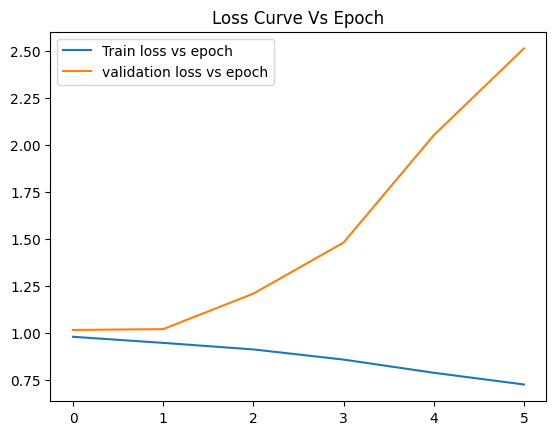

In [24]:
pd.Series(trainer.train_loss).plot(label="Train loss vs epoch")
pd.Series(trainer.val_loss).plot(label="validation loss vs epoch")
plt.title("Loss Curve Vs Epoch")
plt.legend()
plt.show()